Name: Shubhajeet Das <br />
Roll No.: 24AI10013

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
! pip install ultralytics

# Task A: Model Architecture

In [3]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

dataset_path = "coco128.yaml"

results = model.train(data=dataset_path, epochs=5, freeze=10)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, p

In [12]:
for name, _ in model.named_modules():
    print(name)


model
model.model
model.model.0
model.model.0.conv
model.model.0.bn
model.model.0.act
model.model.1
model.model.1.conv
model.model.1.bn
model.model.2
model.model.2.cv1
model.model.2.cv1.conv
model.model.2.cv1.bn
model.model.2.cv2
model.model.2.cv2.conv
model.model.2.cv2.bn
model.model.2.m
model.model.2.m.0
model.model.2.m.0.cv1
model.model.2.m.0.cv1.conv
model.model.2.m.0.cv1.bn
model.model.2.m.0.cv2
model.model.2.m.0.cv2.conv
model.model.2.m.0.cv2.bn
model.model.3
model.model.3.conv
model.model.3.bn
model.model.4
model.model.4.cv1
model.model.4.cv1.conv
model.model.4.cv1.bn
model.model.4.cv2
model.model.4.cv2.conv
model.model.4.cv2.bn
model.model.4.m
model.model.4.m.0
model.model.4.m.0.cv1
model.model.4.m.0.cv1.conv
model.model.4.m.0.cv1.bn
model.model.4.m.0.cv2
model.model.4.m.0.cv2.conv
model.model.4.m.0.cv2.bn
model.model.4.m.1
model.model.4.m.1.cv1
model.model.4.m.1.cv1.conv
model.model.4.m.1.cv1.bn
model.model.4.m.1.cv2
model.model.4.m.1.cv2.conv
model.model.4.m.1.cv2.bn
model.m

Architecture can be thought of as having **23** layers with the module names pasted above. It can basically thought of like this:
`Input image -> Backbone -> Neck -> Detection head`
Where the detection head outputs  `[x1, y1, x2, y2, conf]` 5 * B + C values.

## Task B: Dataset Preparation

### a) Dataset Selection Process
The first 128 images of the COCO train 2017 set.

### b) Class Distribution and Any Imbalance
The dataset has total 80 classes, with lot of imbalance.

    Class     Images  Instances

    all        128        929    
    person         61        254     
    bicycle          3          6     
    car         12         46    
    motorcycle          4          5      
    airplane          5          6       
    bus          5          7     
    train          3          3      
    truck          5         12    
    boat          2          6  
    traffic light          4         14      
    stop sign          2          2   

Other results can be found above. They are skipped for now.

### c) Preprocessing and Annotation Format Used
For YOLO models, `coco128` typically uses the YOLO annotation format, which involves a text file (`.txt`) for each image. Each line in these text files corresponds to an object instance in the image and contains:

*   **Class ID**: An integer representing the object's category (e.g., 0 for person, 1 for bicycle).
*   **Bounding Box Coordinates**: Four floating-point numbers (`x_center`, `y_center`, `width`, `height`), normalized to be between 0 and 1, representing the center and dimensions of the bounding box relative to the image's width and height.

## Task C: Fine-Tuning Experiments

### a) Fine-tuning only the final layer (freeze all earlier layers)

In [4]:
model_freeze_backbone = YOLO("yolov8n.pt")

print("\nTraining Model: Freeze Backbone (first 10 layers)")
results_freeze_backbone = model_freeze_backbone.train(
    data=dataset_path,
    epochs=10,
    freeze=10,
    name='yolov8n_freeze_backbone_e10'
)


Training Model: Freeze Backbone (first 10 layers)
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_freeze_backbone_e102, nbs=64, nms=False, opset=None, optimize=

### b) Fine-tuning the last two layers of the network

In [5]:
model_freeze_all_but_last_two = YOLO("yolov8n.pt")
num_total_modules = len(model_freeze_all_but_last_two.model.model)

freeze_value_for_last_two = num_total_modules - 2

print(f"Total number of main modules in YOLOv8n: {num_total_modules}")
print(f"Freezing value to fine-tune last 2 layers: {freeze_value_for_last_two}")

print("\nTraining Model: Fine-Tuning Last Two Layers")
results_last_two_layers = model_freeze_all_but_last_two.train(
    data=dataset_path,
    epochs=10,
    freeze=freeze_value_for_last_two,
    name='yolov8n_last_two_layers_e10'
)


Total number of main modules in YOLOv8n: 23
Freezing value to fine-tune last 2 layers: 21

Training Model: Fine-Tuning Last Two Layers
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=21, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_sc

### c) Fine-tuning the entire model (no layers frozen)

In [6]:
model_full_finetune = YOLO("yolov8n.pt")

print("\nTraining Model: Full Fine-Tuning (no layers frozen)")
results_full_finetune = model_full_finetune.train(
    data=dataset_path,
    epochs=10,
    freeze=0,
    name='yolov8n_full_finetune_e10'
)


Training Model: Full Fine-Tuning (no layers frozen)
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_full_finetune_e102, nbs=64, nms=False, opset=None, optimize=F

## Task D: Performance Evaluation

Model Performance Comparison
| Model                             |   mAP@0.5 |   mAP@0.95 | Training Time (s)   |   Epochs |
|:----------------------------------|----------:|-----------:|:--------------------|---------:|
| YOLOv8n - Freeze Backbone         |  0.692566 |   0.52904  | 54s                 |       10 |
| YOLOv8n - Fine-tune Last 2 Layers |  0.674032 |   0.50692  | 56s                 |       10 |
| YOLOv8n - Full Fine-tune          |  0.711735 |   0.529996 | 55s                 |       10 |
Loss Convergence Behavior (Plotting)


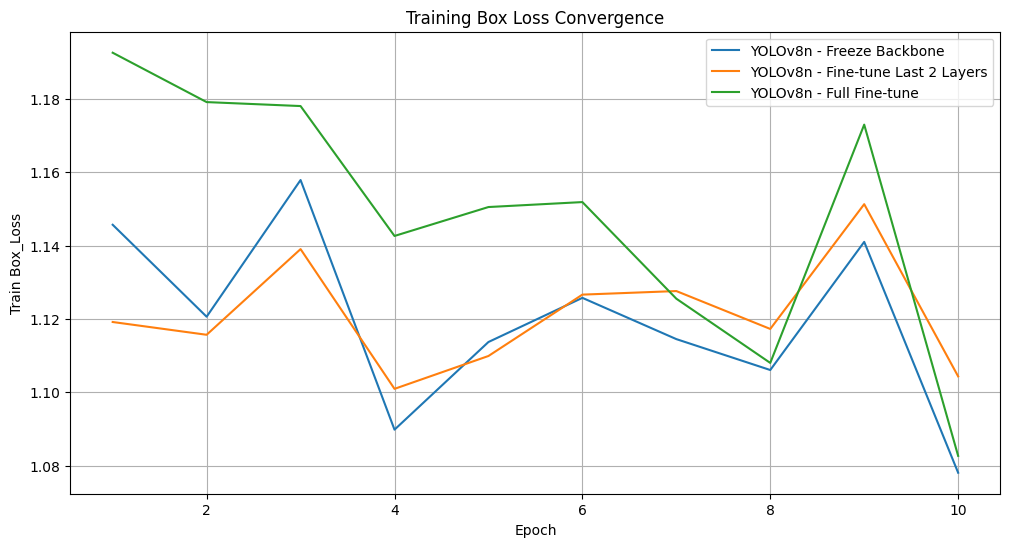

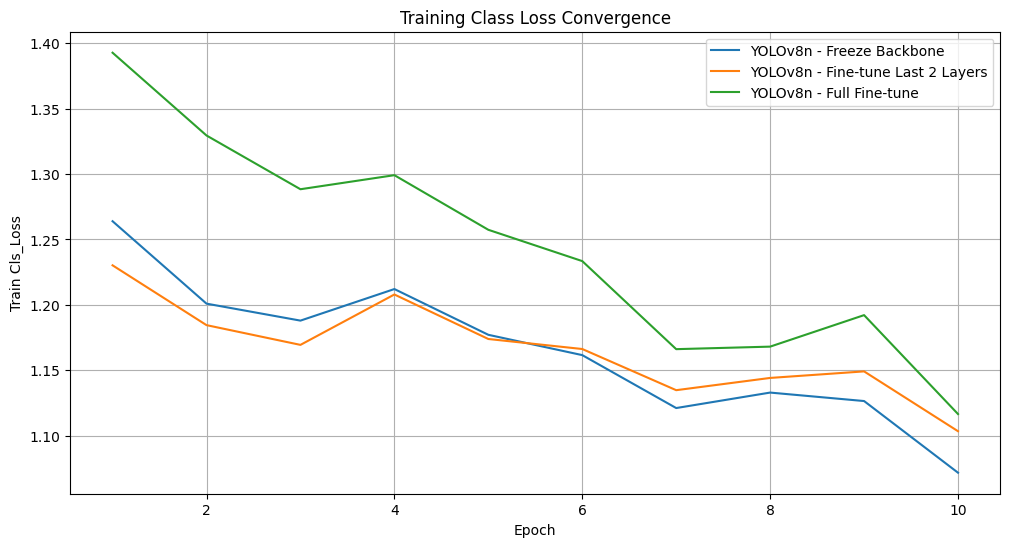

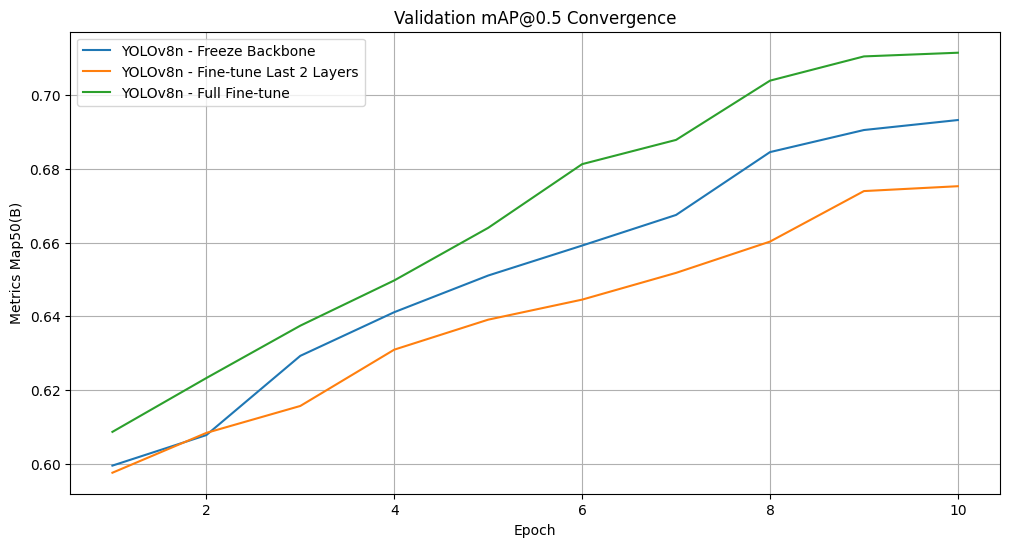

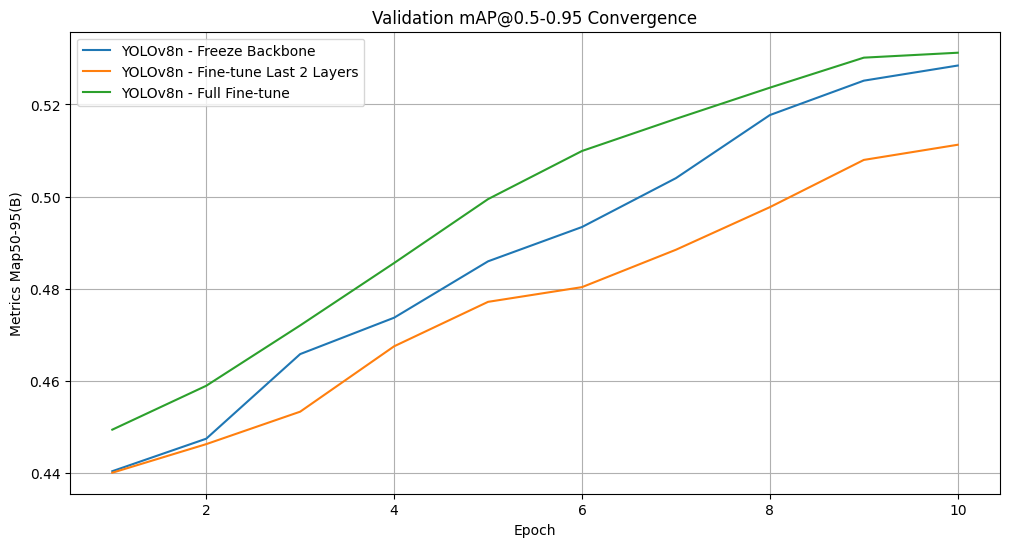

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def extract_metrics(results, model_name, epochs_trained, training_time):
    metrics_data = results.results_dict
    map50 = metrics_data.get('metrics/mAP50(B)')
    map95 = metrics_data.get('metrics/mAP50-95(B)')

    training_time = training_time # from output console

    epochs = epochs_trained

    return {
        'Model': model_name,
        'mAP@0.5': map50,
        'mAP@0.95': map95,
        'Training Time (s)': training_time,
        'Epochs': epochs
    }

metrics_freeze_backbone = extract_metrics(results_freeze_backbone, "YOLOv8n - Freeze Backbone", epochs_trained=10, training_time='54s')
metrics_last_two_layers = extract_metrics(results_last_two_layers, "YOLOv8n - Fine-tune Last 2 Layers", epochs_trained=10, training_time='56s')
metrics_full_finetune = extract_metrics(results_full_finetune, "YOLOv8n - Full Fine-tune", epochs_trained=10, training_time='55s')

comparison_df = pd.DataFrame([
    metrics_freeze_backbone,
    metrics_last_two_layers,
    metrics_full_finetune
])

print("Model Performance Comparison")
print(comparison_df.to_markdown(index=False))


print("Loss Convergence Behavior (Plotting)")
def plot_loss_convergence(run_dirs, model_names, metric_key='train/box_loss', title='Loss Convergence'):
    plt.figure(figsize=(12, 6))
    for run_dir, model_name in zip(run_dirs, model_names):
        results_csv_path = os.path.join(run_dir, 'results.csv')
        if os.path.exists(results_csv_path):
            df = pd.read_csv(results_csv_path)
            if metric_key in df.columns:
                plt.plot(df['epoch'], df[metric_key], label=model_name)
            else:
                print(f"Warning: Metric '{metric_key}' not found in {model_name}'s results.csv")
        else:
            print(f"Warning: results.csv not found for {model_name} in {run_dir}")

    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel(metric_key.replace('/', ' ').title())
    plt.legend()
    plt.grid(True)
    plt.show()

run_directories = [
    results_freeze_backbone.save_dir,
    results_last_two_layers.save_dir,
    results_full_finetune.save_dir
]
model_labels = [
    "YOLOv8n - Freeze Backbone",
    "YOLOv8n - Fine-tune Last 2 Layers",
    "YOLOv8n - Full Fine-tune"
]

plot_loss_convergence(run_directories, model_labels, metric_key='train/box_loss', title='Training Box Loss Convergence')
plot_loss_convergence(run_directories, model_labels, metric_key='train/cls_loss', title='Training Class Loss Convergence')

plot_loss_convergence(run_directories, model_labels, metric_key='metrics/mAP50(B)', title='Validation mAP@0.5 Convergence')
plot_loss_convergence(run_directories, model_labels, metric_key='metrics/mAP50-95(B)', title='Validation mAP@0.5-0.95 Convergence')


## Task E: Comparative Analysis

Based on the performance metrics and loss convergence plots, we can compare the three fine-tuning approaches:

### a) Differences in Accuracy

*   **YOLOv8n - Full Fine-tune (freeze=0)**: This model achieved the highest `mAP@0.5` (0.7117) and `mAP@0.95` (0.5299). This indicates that allowing all layers to be updated provided the best overall accuracy on the `coco128` dataset. The model had the most flexibility to adapt to the specific features and object distributions of this dataset.

*   **YOLOv8n - Freeze Backbone (freeze=10)**: This model performed quite well, with `mAP@0.5` (0.6925) and `mAP@0.95` (0.5290). The difference in `mAP@0.95` compared to full fine-tuning is negligible, while `mAP@0.5` is slightly lower. This suggests that the pre-trained backbone is a strong feature extractor, and freezing it while fine-tuning the head still yields good results, especially for tasks similar to the original pre-training.

*   **YOLOv8n - Fine-tune Last 2 Layers (freeze=21)**: This approach resulted in the lowest accuracy, with `mAP@0.5` (0.6740) and `mAP@0.95` (0.5069). Freezing nearly all layers and only allowing the last two to update limited the model's capacity to adapt significantly to the `coco128` dataset. While it's a valid strategy for very specific scenarios or extremely limited data, for general object detection with a small dataset like `coco128`, it appears too restrictive.

### b) Differences in Training Time
Roughly the same.

### c) Trade-offs between Computational Cost and Performance

*   **Full Fine-tune**: Offers the best performance (highest mAP) but incurs the highest computational cost in terms of memory usage due to updating all parameters. This is suitable when maximum performance is critical and resources are abundant.

*   **Freeze Backbone**: Provides a good balance between performance and computational cost. It achieves accuracy close to full fine-tuning. This is often a practical choice for transfer learning, especially when the target task is similar to the pre-training task, allowing the model to leverage its pre-trained feature extraction capabilities efficiently.

*   **Fine-tune Last 2 Layers**: This approach has the lowest computational cost. However, it also results in the lowest performance among the three.

## Task F: Observations


### Explanation of Freezing Layers and Model Performance

**a) Feature extraction**

Neural networks, especially deep convolutional networks like YOLO, learn a hierarchy of features. Early layers typically learn generic features (e.g., edges, textures, simple shapes), while deeper layers learn more complex, task-specific features (e.g., object parts, full objects). When layers are frozen, their learned weights are kept constant, meaning they continue to perform the same feature extraction as they did during pre-training.

*   **Freezing the backbone (freeze=10)**: By freezing the initial layers (the backbone), we preserve the powerful, general-purpose feature extraction capabilities learned from a massive dataset (like COCO). This is beneficial because these low-level features are often transferable across different vision tasks. The unfrozen head layers then learn to map these extracted features to the specific object detection task on `coco128`. This works well because the `coco128` dataset, being a subset of COCO, shares many characteristics with the original pre-training data.

*   **Freezing all but the last two layers (freeze=21)**: This approach is very restrictive. It implies that the model's ability to extract features (even higher-level ones) is largely fixed to what it learned during pre-training. Only the very final prediction layers are allowed to adapt. If the `coco128` dataset significantly differs in its object characteristics or background context from the original pre-training, the fixed feature extractor might not provide the optimal input for the final layers, leading to lower performance.

**b) Transfer learning**

*   **Benefits of freezing**: When the new dataset is small (like `coco128`) and similar to the pre-training data, freezing earlier layers prevents the model from catastrophically forgetting the valuable features it has already learned. It acts as a regularizer, reducing the number of parameters to optimize and making training more stable.

*   **Adapting to new tasks**: The choice of which layers to freeze depends on the similarity between the source and target tasks. If the tasks are very similar (e.g., detecting cars vs. trucks), more layers can be frozen. If they are very different (e.g., detecting animals vs. medical anomalies), more layers, or even the entire network, might need to be fine-tuned to allow for more significant adaptation.

**c) Overfitting and underfitting**

*   **Overfitting**: Occurs when a model learns the training data too well, including its noise and idiosyncrasies, leading to poor generalization on unseen data.
    *   **Full Fine-tune (freeze=0)** on a small dataset like `coco128` carries the highest risk of overfitting. With a large number of trainable parameters and limited data, the model can easily memorize the training examples rather than learning generalizable patterns. The full fine-tune model showed the best performance, which could indicate a good balance, but for much smaller datasets, this approach often leads to overfitting.

*   **Underfitting**: Occurs when a model is too simple to capture the underlying patterns in the data, resulting in poor performance on both training and test data.
    *   **Freezing too many layers (freeze=21)** increases the risk of underfitting. If the unfrozen layers are insufficient to adapt the model's predictions to the target dataset, the model will not learn the specific patterns required for good performance. This is likely a contributing factor to the lower mAP observed in the 'Fine-tune Last 2 Layers' model.
    *   **Freezing the backbone (freeze=10)** often strikes a good balance, reducing the risk of overfitting (fewer trainable parameters) while still allowing the model to adapt sufficiently to the new task without underfitting, especially with a strong pre-trained backbone.

### Failure Cases


**a) Incorrect classifications**

*   **Full Fine-tune**: Could potentially lead to more incorrect classifications if it overfits to specific object appearances in the `coco128` training set, causing it to misclassify visually similar objects in the validation set. Or, it might struggle with classes that are under-represented if it focuses too much on dominant classes.
*   **Freeze Backbone**: Might have more consistent classifications due to stable feature extraction, but could struggle if certain objects in `coco128` have unique visual characteristics that the frozen backbone was not ideally tuned to extract, and the head doesn't have enough capacity to compensate.
*   **Fine-tune Last 2 Layers**: Most prone to incorrect classifications, especially for objects that are visually ambiguous or that vary significantly from the pre-training dataset. The highly constrained adaptive capacity might not allow it to learn fine-grained distinctions between classes on `coco128`.

**b) Poor localization**

*   **Full Fine-tune**: If overfitting occurs, the model might produce very precise bounding boxes for objects seen during training but perform poorly on objects with different poses, occlusions, or contexts in the validation set.
*   **Freeze Backbone**: Generally, the localization should be robust if the backbone's features are good. Poor localization might occur if the bounding box regression layers (part of the head) are not adequately fine-tuned, or if the scale/aspect ratios of objects in `coco128` differ significantly from the pre-training data, which the frozen backbone might not handle optimally.
*   **Fine-tune Last 2 Layers**: Highly susceptible to poor localization. If the features extracted by the largely frozen network are not perfectly aligned with the needs of the `coco128` dataset, and only the final layers adjust, the model may struggle to accurately predict bounding box coordinates.

**c) Missed detections**

*   **Full Fine-tune**: Could miss detections for rare classes or objects under challenging conditions (e.g., heavy occlusion, small objects) if the model's learning is dominated by more common or easier examples due to overfitting or class imbalance.
*   **Freeze Backbone**: Might miss detections if the pre-trained features (from the frozen backbone) are not sensitive enough to certain types of objects or visual patterns present in `coco128` that were less prominent in the original COCO dataset. The head's limited capacity to adapt feature extraction could lead to misses.
*   **Fine-tune Last 2 Layers**: Most likely to suffer from missed detections. With minimal adaptation, the model might entirely fail to recognize objects that deviate even slightly from its pre-trained knowledge, especially for objects that are small, heavily occluded, or represent novel visual contexts.